In [1]:
!pip install pytorch_msssim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 25.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-

Epoch 1, Loss: 0.2166, SSIM: 0.7335
Epoch 2, Loss: 0.1454, SSIM: 0.8306
Epoch 3, Loss: 0.1113, SSIM: 0.8811
Epoch 4, Loss: 0.0890, SSIM: 0.9079
Epoch 5, Loss: 0.0820, SSIM: 0.9162
Epoch 6, Loss: 0.0773, SSIM: 0.9220
Epoch 7, Loss: 0.0741, SSIM: 0.9260
Epoch 8, Loss: 0.0701, SSIM: 0.9310
Epoch 9, Loss: 0.0681, SSIM: 0.9338
Epoch 10, Loss: 0.0655, SSIM: 0.9369
Epoch 11, Loss: 0.0640, SSIM: 0.9389
Epoch 12, Loss: 0.0622, SSIM: 0.9409
Epoch 13, Loss: 0.0617, SSIM: 0.9416
Epoch 14, Loss: 0.0612, SSIM: 0.9423
Epoch 15, Loss: 0.0612, SSIM: 0.9423
Epoch 16, Loss: 0.0604, SSIM: 0.9433
Epoch 17, Loss: 0.0595, SSIM: 0.9446
Epoch 18, Loss: 0.0594, SSIM: 0.9448
Epoch 19, Loss: 0.0592, SSIM: 0.9451
Epoch 20, Loss: 0.0587, SSIM: 0.9457
Epoch 21, Loss: 0.0590, SSIM: 0.9456
Epoch 22, Loss: 0.0576, SSIM: 0.9474
Epoch 23, Loss: 0.0573, SSIM: 0.9480
Epoch 24, Loss: 0.0580, SSIM: 0.9472
Epoch 25, Loss: 0.0568, SSIM: 0.9490
Epoch 26, Loss: 0.0565, SSIM: 0.9494
Epoch 27, Loss: 0.0561, SSIM: 0.9501
Epoch 28, 

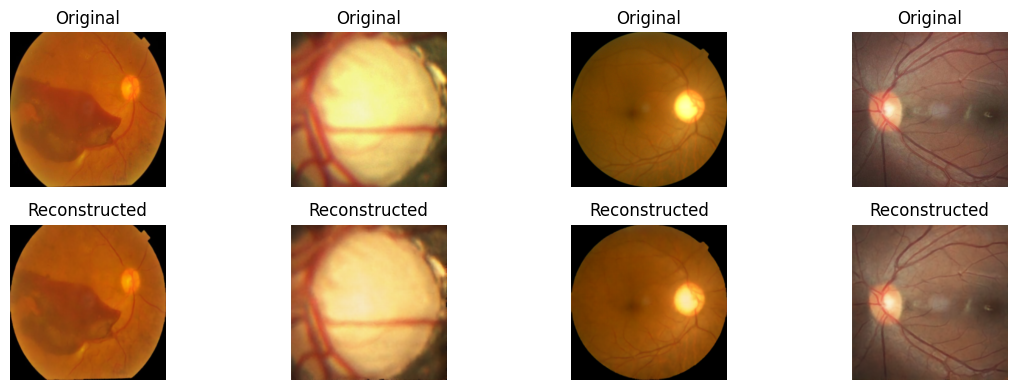

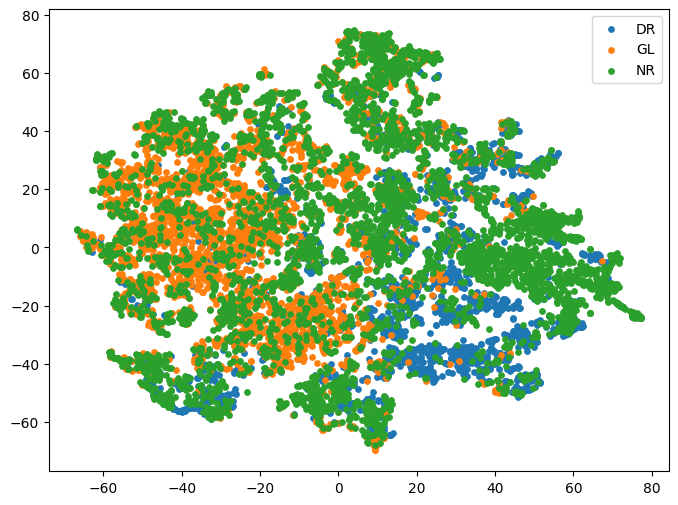

Reconstruction plots with SSIM saved in 'reconstructions/' folder.


NameError: name 'kaggle' is not defined

In [6]:
# VAE with VirtualPatchCNNEncoder for Image Reconstruction + Training, SSIM, t-SNE
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as compare_ssim
import numpy as np
from PIL import Image

# Encoder from earlier
class VirtualPatchCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=1024):
        super(VirtualPatchCNNEncoder, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.z_mean = nn.Conv2d(256, latent_dim, kernel_size=1)
        self.z_log_var = nn.Conv2d(256, latent_dim, kernel_size=1)

    def forward(self, x):
        x = self.conv_layers(x)
        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)
        return z_mean, z_log_var

class Sampling(nn.Module):
    def forward(self, z_mean, z_log_var):
        epsilon = torch.randn_like(z_mean)
        return z_mean + torch.exp(0.5 * z_log_var) * epsilon

class VAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=1024):
        super(VAE, self).__init__()
        self.encoder = VirtualPatchCNNEncoder(in_channels, latent_dim)
        self.sampling = Sampling()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(64, in_channels, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.sampling(z_mean, z_log_var)
        x_recon = self.decoder(z)
        return x_recon, z_mean, z_log_var, z
"""
def vae_loss(x, x_recon, z_mean, z_log_var):
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
    return recon_loss + kl_loss
"""
from pytorch_msssim import ssim

def vae_loss(x, x_recon, z_mean, z_log_var, alpha=0.1):
    # MSE loss
    mse_loss = F.mse_loss(x_recon, x, reduction='mean')

    # SSIM loss (returns similarity, so we subtract from 1)
    ssim_loss = 1 - ssim(x, x_recon, data_range=1.0, size_average=True)

    # KL Divergence
    kl_loss = -0.5 * torch.mean(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())

    # Weighted sum: α*MSE + (1-α)*SSIM + KL
    total_loss = alpha * mse_loss + (1 - alpha) * ssim_loss + kl_loss
    return total_loss

def compute_ssim(x, x_recon):
    ssim_scores = []
    # Detach tensors before converting to numpy
    x = x.detach().permute(0, 2, 3, 1).cpu().numpy()
    x_recon = x_recon.detach().permute(0, 2, 3, 1).cpu().numpy()
    for i in range(x.shape[0]):
        score = compare_ssim(x[i], x_recon[i], channel_axis=-1, data_range=1.0)
        ssim_scores.append(score)
    return np.mean(ssim_scores)
# Data loading
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

image_dir = "/kaggle/input/fundus/Train"  # Update this"/kaggle/input/fundus-dataset-1/Train"
dataset = ImageFolder(root=image_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

train_loss_list, ssim_list = [], []
for epoch in range(50):
    vae.train()
    total_loss, total_ssim = 0, 0
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_recon, z_mean, z_log_var, z = vae(imgs)
        loss = vae_loss(imgs, x_recon, z_mean, z_log_var)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_ssim += compute_ssim(imgs, x_recon)
    avg_loss = total_loss / len(dataloader)
    avg_ssim = total_ssim / len(dataloader)
    train_loss_list.append(avg_loss)
    ssim_list.append(avg_ssim)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, SSIM: {avg_ssim:.4f}")

# Visualization of input vs reconstruction
vae.eval()
with torch.no_grad():
    imgs, _ = next(iter(dataloader))
    imgs = imgs.to(device)
    recon, _, _, _ = vae(imgs)
    imgs = imgs.cpu().numpy()
    recon = recon.cpu().numpy()
    plt.figure(figsize=(12, 4))
    for i in range(4):
        plt.subplot(2, 4, i+1)
        plt.imshow(np.transpose(imgs[i], (1, 2, 0)))
        plt.axis('off')
        plt.title("Original")
        plt.subplot(2, 4, i+5)
        plt.imshow(np.transpose(recon[i], (1, 2, 0)))
        plt.axis('off')
        plt.title("Reconstructed")
    #plt.suptitle("Image Reconstruction by VAE")
    plt.tight_layout()
    plt.savefig("/kaggle/working/Reconstruction_1024.png")
    plt.show()

# t-SNE visualization of latent features
from sklearn.manifold import TSNE
vae.eval()
all_z, all_labels = [], []
with torch.no_grad():
    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        _, _, _, z = vae(imgs)
        z = z.mean(dim=[2, 3]).cpu().numpy()  # global avg pool
        all_z.append(z)
        all_labels.extend(labels.numpy())

z = np.concatenate(all_z, axis=0)
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z)

plt.figure(figsize=(8, 6))
for i in np.unique(all_labels):
    idxs = np.array(all_labels) == i
    plt.scatter(z_2d[idxs, 0], z_2d[idxs, 1], label=dataset.classes[i], s=15)
plt.legend()
#plt.title("t-SNE of VAE Latent Features")
plt.savefig("/kaggle/working/TSNE_1024.png")
plt.show()

########################################

import os
os.makedirs("/kaggle/working/reconstructions", exist_ok=True)

vae.eval()
with torch.no_grad():
    # Dictionary to track saved classes
    saved_classes = {}
    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        recon, _, _, _ = vae(imgs)
        for i in range(imgs.size(0)):
            class_idx = labels[i].item()
            class_name = dataset.classes[class_idx]
            if class_name not in saved_classes:
                # Get SSIM score
                ssim_score = compare_ssim(
                    imgs[i].permute(1, 2, 0).cpu().numpy(),
                    recon[i].permute(1, 2, 0).cpu().numpy(),
                    data_range=1.0,
                    channel_axis=-1
                )

                # Plot
                plt.figure(figsize=(6, 3))
                plt.subplot(1, 2, 1)
                plt.imshow(imgs[i].permute(1, 2, 0).cpu().numpy())
                plt.axis('off')
                plt.title("Original")

                plt.subplot(1, 2, 2)
                plt.imshow(recon[i].permute(1, 2, 0).cpu().numpy())
                plt.axis('off')
                plt.title(f"Recon\nSSIM: {ssim_score:.4f}")

                plt.suptitle(f"Class: {class_name}")
                plt.tight_layout()
                plt.savefig(f"reconstructions/{class_name}_reconstruction.png")
                plt.close()

                saved_classes[class_name] = True

        # Stop if all classes are covered
        if len(saved_classes) == len(dataset.classes):
            break
print("Reconstruction plots with SSIM saved in 'reconstructions/' folder.")


encoder = vae.encoder
# Save the encoder weights (state_dict)
torch.save(encoder.state_dict(), "/kaggle/working/encoder_1024.pth")
print(f"Encoder model saved to" /kaggle/working/encoder_1024.pth)

# Save entire VAE model
torch.save(vae.state_dict(), "kaggle/working/vae_1024.pth")
from torchinfo import summary

encoder = VirtualPatchCNNEncoder(in_channels=3, latent_dim=1024).to(device)
summary(encoder, input_size=(1, 3, 256, 256))

vae = VAE(in_channels=3, latent_dim=1024).to(device)
summary(vae, input_size=(1, 3, 256, 256))


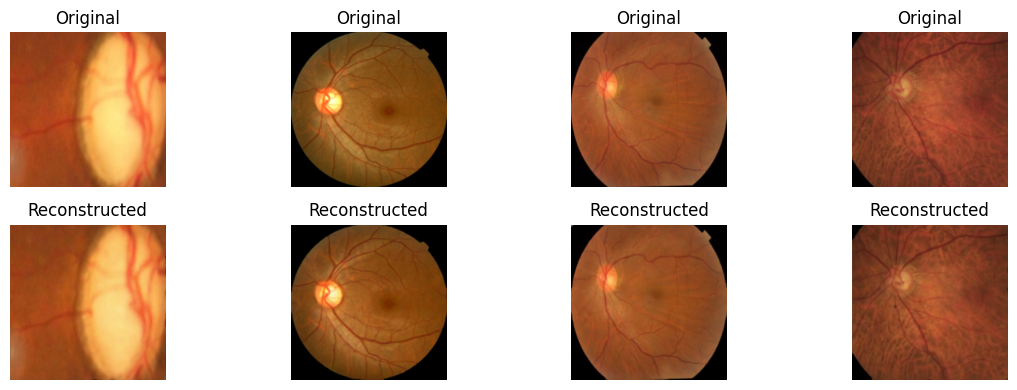

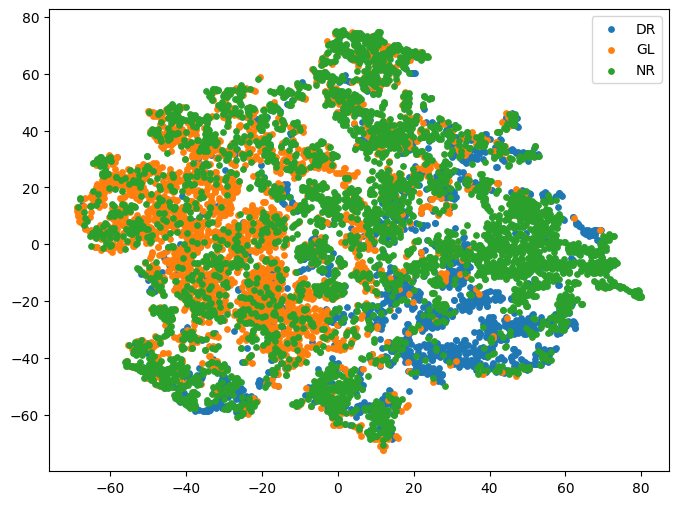

Reconstruction plots with SSIM saved in 'reconstructions/' folder.
Encoder model saved to /kaggle/working/encoder_1024.pth


Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 3, 256, 256]          --
├─VirtualPatchCNNEncoder: 1-1            [1, 1024, 32, 32]         --
│    └─Sequential: 2-1                   [1, 256, 32, 32]          --
│    │    └─Conv2d: 3-1                  [1, 32, 256, 256]         896
│    │    └─ReLU: 3-2                    [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-3                  [1, 64, 128, 128]         18,496
│    │    └─ReLU: 3-4                    [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-5                  [1, 128, 64, 64]          73,856
│    │    └─ReLU: 3-6                    [1, 128, 64, 64]          --
│    │    └─Conv2d: 3-7                  [1, 256, 32, 32]          295,168
│    │    └─ReLU: 3-8                    [1, 256, 32, 32]          --
│    └─Conv2d: 2-2                       [1, 1024, 32, 32]         263,168
│    └─Conv2d: 2-3                       [1, 1024, 32, 32]        

In [7]:

# Visualization of input vs reconstruction
vae.eval()
with torch.no_grad():
    imgs, _ = next(iter(dataloader))
    imgs = imgs.to(device)
    recon, _, _, _ = vae(imgs)
    imgs = imgs.cpu().numpy()
    recon = recon.cpu().numpy()
    plt.figure(figsize=(12, 4))
    for i in range(4):
        plt.subplot(2, 4, i+1)
        plt.imshow(np.transpose(imgs[i], (1, 2, 0)))
        plt.axis('off')
        plt.title("Original")
        plt.subplot(2, 4, i+5)
        plt.imshow(np.transpose(recon[i], (1, 2, 0)))
        plt.axis('off')
        plt.title("Reconstructed")
    #plt.suptitle("Image Reconstruction by VAE")
    plt.tight_layout()
    plt.savefig("/kaggle/working/Reconstruction_1024.png")
    plt.show()

# t-SNE visualization of latent features
from sklearn.manifold import TSNE
vae.eval()
all_z, all_labels = [], []
with torch.no_grad():
    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        _, _, _, z = vae(imgs)
        z = z.mean(dim=[2, 3]).cpu().numpy()  # global avg pool
        all_z.append(z)
        all_labels.extend(labels.numpy())

z = np.concatenate(all_z, axis=0)
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z)

plt.figure(figsize=(8, 6))
for i in np.unique(all_labels):
    idxs = np.array(all_labels) == i
    plt.scatter(z_2d[idxs, 0], z_2d[idxs, 1], label=dataset.classes[i], s=15)
plt.legend()
#plt.title("t-SNE of VAE Latent Features")
plt.savefig("/kaggle/working/TSNE_1024.png")
plt.show()

########################################

import os
os.makedirs("/kaggle/working/reconstructions", exist_ok=True)

vae.eval()
with torch.no_grad():
    # Dictionary to track saved classes
    saved_classes = {}
    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        recon, _, _, _ = vae(imgs)
        for i in range(imgs.size(0)):
            class_idx = labels[i].item()
            class_name = dataset.classes[class_idx]
            if class_name not in saved_classes:
                # Get SSIM score
                ssim_score = compare_ssim(
                    imgs[i].permute(1, 2, 0).cpu().numpy(),
                    recon[i].permute(1, 2, 0).cpu().numpy(),
                    data_range=1.0,
                    channel_axis=-1
                )

                # Plot
                plt.figure(figsize=(6, 3))
                plt.subplot(1, 2, 1)
                plt.imshow(imgs[i].permute(1, 2, 0).cpu().numpy())
                plt.axis('off')
                plt.title("Original")

                plt.subplot(1, 2, 2)
                plt.imshow(recon[i].permute(1, 2, 0).cpu().numpy())
                plt.axis('off')
                plt.title(f"Recon\nSSIM: {ssim_score:.4f}")

                plt.suptitle(f"Class: {class_name}")
                plt.tight_layout()
                plt.savefig(f"reconstructions/{class_name}_reconstruction.png")
                plt.close()

                saved_classes[class_name] = True

        # Stop if all classes are covered
        if len(saved_classes) == len(dataset.classes):
            break
print("Reconstruction plots with SSIM saved in 'reconstructions/' folder.")


encoder = vae.encoder
# Save the encoder weights (state_dict)
torch.save(encoder.state_dict(), "/kaggle/working/encoder_1024.pth")
print(f"Encoder model saved to /kaggle/working/encoder_1024.pth")

# Save entire VAE model
torch.save(vae.state_dict(), "/kaggle/working/vae_1024.pth")
from torchinfo import summary

encoder = VirtualPatchCNNEncoder(in_channels=3, latent_dim=1024).to(device)
summary(encoder, input_size=(1, 3, 256, 256))

vae = VAE(in_channels=3, latent_dim=1024).to(device)
summary(vae, input_size=(1, 3, 256, 256))
